In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
t = torch.tensor([1, 2, 3])
print(t[0].item()) # to access the value of a 0-dim tensor as a standard Python number. It is used to extract the single value from a tensor that contains only one element, allowing you to work with it as a regular Python scalar.
print(t.exp())
print(t.log())
print(t.sum().item())

1
tensor([ 2.7183,  7.3891, 20.0855])
tensor([0.0000, 0.6931, 1.0986])
6


In [3]:
# random seed in torch
torch.manual_seed(42) # pytorch use this seed automatically; and it automatically change(increment) it's(RNG random number generator) state after each call to a random functions, BUT if you want to reproduce the same results, you can set it again to the same value before calling another random functions
g = torch.Generator().manual_seed(42) # similar to the above but instead it is passed explicitly to the random functions

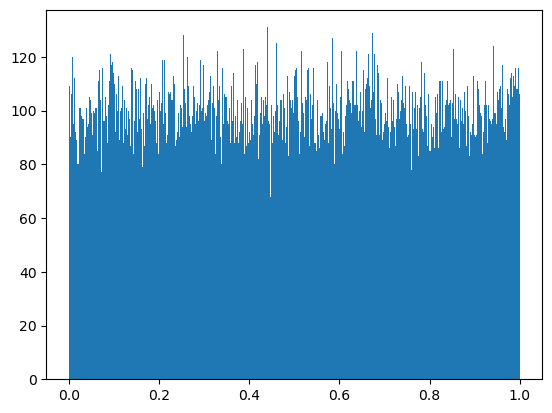

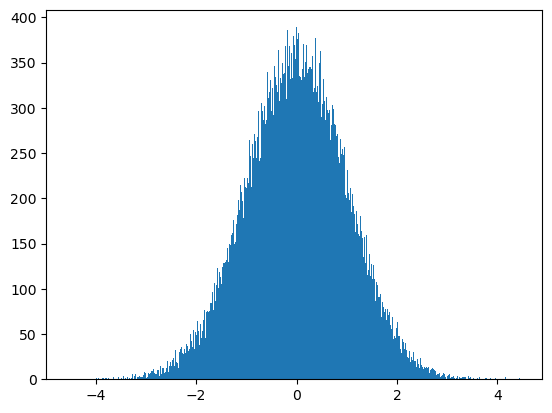

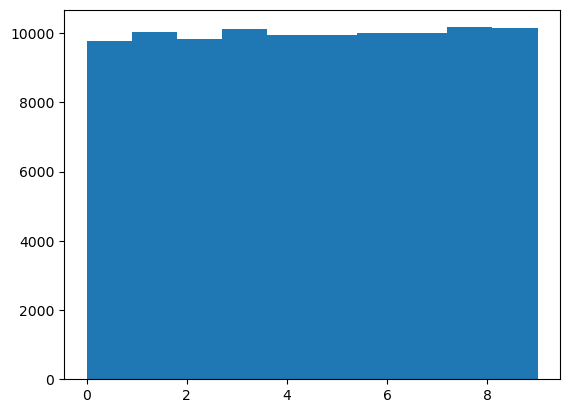

In [4]:
# random tensors in torch
torch.manual_seed(42)

# torch.rand(size)
# -> Uniform distribution in [0, 1)
# -> Returns FLOAT tensor
torch.rand(3)      # e.g. tensor([0.88, 0.91, 0.38])
plt.hist(torch.rand(100_000), bins=1000)
plt.show()

# torch.randn(size)
# -> Normal/Gaussian distribution (mean=0, std=1)
# -> Returns FLOAT tensor
torch.randn(3)     # e.g. tensor([ 0.34, -1.12,  0.23])
plt.hist(torch.randn(100_000), bins=1000)
plt.show()

# torch.randint(low, high, size)
# -> Uniform random INTEGERS in [low, high)
# -> Returns INT tensor
torch.randint(0, 10, (3,))  # e.g. tensor([2, 7, 6])
plt.hist(torch.randint(0, 10, (100_000,)), bins=10)
plt.show()

In [5]:
# tensor dimensions and the broadcasting in torch
t = torch.rand((27, 27))

print(t.sum(0).shape)
print(t.sum(0, keepdims=True).shape)

t_sum = t.sum(1, keepdims=True) # (27, 1)
t_res = t / t_sum # (27, 27) / (27, 1) -> broadcasting to (27, 27)

print(t_res.sum().shape) # add up all the elements from all the dimensions and return a single scalar value, resulting in a tensor of shape ().
print(t_res.sum(1).shape) # add up the elements across the columns for each row, resulting in a 1D tensor of shape (27,)
print(t_res.sum(1, keepdims=True).shape) # add up the elements across the columns for each row, resulting in a 2D tensor of shape (27, 1) due to keepdims=True, which keeps the original number of dimensions.

torch.Size([27])
torch.Size([1, 27])
torch.Size([])
torch.Size([27])
torch.Size([27, 1])


torch.Size([1])


(array([7.790e+02, 2.730e+03, 4.032e+03, 4.603e+03, 4.878e+03, 4.711e+03,
        4.640e+03, 4.512e+03, 4.144e+03, 3.860e+03, 3.650e+03, 3.491e+03,
        3.120e+03, 2.952e+03, 2.743e+03, 2.503e+03, 2.346e+03, 2.171e+03,
        1.965e+03, 1.885e+03, 1.760e+03, 1.674e+03, 1.553e+03, 1.445e+03,
        1.405e+03, 1.235e+03, 1.236e+03, 1.041e+03, 1.046e+03, 9.800e+02,
        8.960e+02, 8.560e+02, 7.950e+02, 7.760e+02, 7.120e+02, 6.240e+02,
        6.670e+02, 6.150e+02, 6.060e+02, 5.460e+02, 4.820e+02, 5.500e+02,
        4.810e+02, 4.410e+02, 4.370e+02, 4.130e+02, 3.970e+02, 3.720e+02,
        3.690e+02, 3.480e+02, 3.270e+02, 3.160e+02, 3.090e+02, 3.090e+02,
        2.670e+02, 2.770e+02, 2.790e+02, 2.260e+02, 2.390e+02, 2.060e+02,
        2.330e+02, 2.160e+02, 2.110e+02, 1.990e+02, 1.800e+02, 1.740e+02,
        1.990e+02, 1.670e+02, 1.490e+02, 1.280e+02, 1.330e+02, 1.480e+02,
        1.510e+02, 1.100e+02, 1.290e+02, 1.280e+02, 1.200e+02, 1.160e+02,
        1.070e+02, 1.150e+02, 1.130e+0

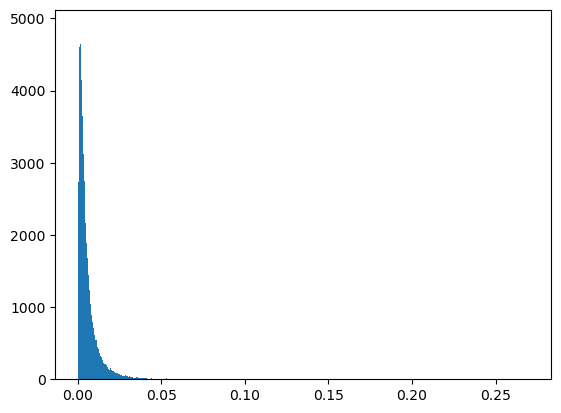

In [6]:
# multinomial sampling
# higher probability means more likely to be chosen, it returns the index of the chosen character

p = torch.randn((100000,)) # (1000,) mean 0, std 1, 100 random numbers, more number near 0
print(p.sum(0, keepdims=True).shape)
p = p.exp()/p.sum(0, keepdims=True) # softmax function, it converts the raw scores (logits) into probabilities that sum to 1

plt.hist(p, bins=1000)

# p = p.float()
# p = p / p.sum() # normalization
# # ix = torch.multinomial(p, num_samples=100, replacement=True).item() # sample from the distribution based on the probabilities in p, higher probability means more likely to be chosen, it returns the index of the chosen character

# plt.bar(torch.arange(100), p)

In [7]:
# predicting the next character based on the distribution, only for the first character "."
torch.manual_seed(42)
ix = torch.multinomial(p, num_samples=1, replacement=True).item() # sample from the distribution based on the probabilities in p, higher probability means more likely to be chosen, it returns the index of the chosen character
itos[ix]

NameError: name 'itos' is not defined

In [ ]:
rand    -> random floats  [0,1)
randn   -> random normal  N(0,1)
randint -> random integers

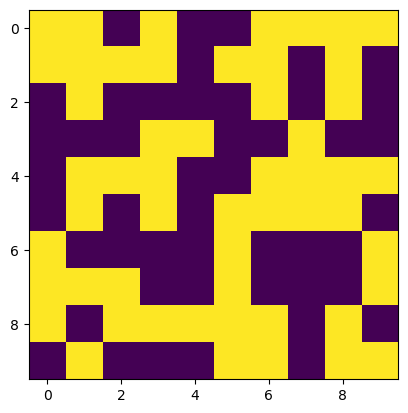

In [ ]:
t = torch.randint(0, 2, (10, 10))
plt.imshow(t)

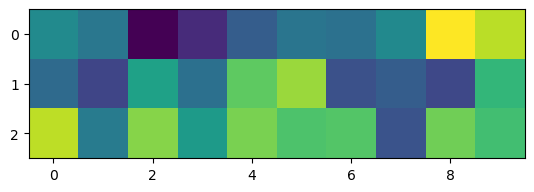

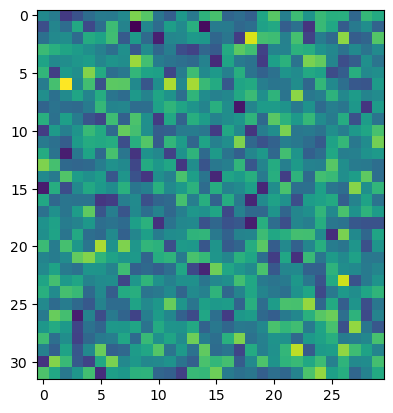

In [ ]:
t = torch.randn((32, 3, 10))
plt.imshow(t[0])
plt.show()

plt.imshow(t.view(-1, 3 * 10))

In [ ]:
import torch

# ── Simple Indexing ──────────────────────────────────────────────────────────
# Uses scalars or slices only. Always returns a VIEW (shared memory, no copy).

t = torch.randn((27, 27))  # shape: (27, 27)

# --- Row / Column selection ---
print(t[0])         # shape: (27,)   — row 0,    drops first dim
print(t[-1])        # shape: (27,)   — last row, drops first dim
print(t[:, 0])      # shape: (27,)   — col 0,    drops second dim
print(t[:, -1])     # shape: (27,)   — last col, drops second dim

# --- Scalar (single element) ---
print(t[0, 0])      # shape: ()      — scalar, both dims dropped
print(t[3, 7])      # shape: ()      — element at row 3, col 7

# --- Slicing (range of rows/cols) ---
print(t[0:5])       # shape: (5, 27)  — rows 0-4, all cols
print(t[:, 0:5])    # shape: (27, 5)  — all rows, cols 0-4
print(t[0:5, 0:5])  # shape: (5, 5)   — top-left 5x5 block
print(t[::2])       # shape: (14, 27) — every other row (step=2)

# --- Keeping dims with slice vs scalar ---
print(t[0].shape)       # (27,)   — dim dropped  (scalar index)
print(t[0:1].shape)     # (1, 27) — dim kept     (slice index)
print(t[:, 0].shape)    # (27,)   — dim dropped
print(t[:, 0:1].shape)  # (27, 1) — dim kept


# ── Advanced (Fancy) Indexing ────────────────────────────────────────────────
# Uses integer tensors of any shape as indices.
# Always returns a COPY (not a view).
#
# Rule:  output.shape = index.shape + tensor.shape[1:]
#        (index replaces the first dimension of the tensor)

t = torch.randn((27, 27))  # shape: (27, 27)

# --- 1D index on 2D tensor ---
# index.shape=(10,), tensor.shape=(27,27) → output=(10,)+(27,) = (10, 27)
idxs = torch.randint(0, 27, (10,))  # shape: (10,)
print(t[idxs])                       # shape: (10, 27) — 10 selected rows

# --- 2D index on 2D tensor (embedding lookup) ---
# index.shape=(10,3), tensor.shape=(27,2) → output=(10,3)+(2,) = (10, 3, 2)
Xtr = torch.randint(0, 27, (10, 3))  # shape: (10, 3) — 10 contexts, length 3
C   = torch.randn((27, 2))           # shape: (27, 2) — 27 tokens, embed_dim=2
emb = C[Xtr]                         # shape: (10, 3, 2)
#
# what happens step by step:
#   Xtr[0]    = [4, 15, 22]           — context 0: 3 token ids
#   C[4]      = [x, x]                — embedding of token 4,  shape: (2,)
#   C[15]     = [x, x]                — embedding of token 15, shape: (2,)
#   C[22]     = [x, x]                — embedding of token 22, shape: (2,)
#   emb[0]    = [[x,x],[x,x],[x,x]]  — 3 embeddings stacked,  shape: (3, 2)
#   emb       → all 10 contexts       —                        shape: (10, 3, 2)

# --- 3D index on 2D tensor ---
# index.shape=(2,4,3), tensor.shape=(27,2) → output=(2,4,3)+(2,) = (2, 4, 3, 2)
Xbatch = torch.randint(0, 27, (2, 4, 3))  # shape: (2, 4, 3)
emb2   = C[Xbatch]                         # shape: (2, 4, 3, 2)


# ── Boolean (Mask) Indexing ──────────────────────────────────────────────────
# Uses a bool tensor as a mask. Always returns a COPY.
# Flattens the masked dimension → output is always 1D along that axis.

t = torch.randn((5, 4))   # shape: (5, 4)

# --- Mask on entire tensor (element-wise) ---
mask = t > 0              # shape: (5, 4), dtype: bool
print(t[mask])            # shape: (N,)   — N = number of True values, unpredictable

# --- Mask on rows (1D mask over first dim) ---
row_mask = torch.tensor([True, False, True, False, True])  # shape: (5,)
print(t[row_mask])        # shape: (3, 4) — only rows where mask is True

# --- Practical use: ignore padding tokens in loss ---
# targets shape : (B, T) = (8, 16)
# loss    shape : (B, T) = (8, 16)
B, T     = 8, 16
pad_id   = 0
targets  = torch.randint(0, 27, (B, T))   # shape: (8, 16)
loss_all = torch.randn((B, T))            # shape: (8, 16)  — per-token loss
mask     = targets != pad_id              # shape: (8, 16), dtype: bool
loss     = loss_all[mask].mean()          # shape: ()  — scalar, pads excluded

In [ ]:
Ytr = torch.randint(0, 27, (32,))
torch.manual_seed(42)
logits = torch.randn((32, 27))

c_loss = F.cross_entropy(logits, Ytr)
print(c_loss)

# prob = -F.softmax(logits, dim=1).log() # in built softmax
temp = logits.exp() / logits.exp().sum(dim=1, keepdim=True)
prob = -temp.log()
nll = prob.mean()
print(nll)



tensor(3.6070)
tensor(3.7624)


In [ ]:
torch.randn(20).nelement()

20

In [ ]:
nn.Linear(10, 5).weight.numel()

50

In [8]:
a = torch.randn(5)
b = torch.randn(5)

_2d = torch.stack([a, b])
_2d.shape


torch.Size([2, 5])